<img src="./logo_UNSAM.jpg" align="right" width="150" /> 

#### Análisis y Procesamiento de Señales

# Trabajo Práctico Nº1
#### Manuel Helas
En este trabajo se van a geenrar una señal semouidal asi como una rectangular siempre utilizando N = 1000 muestras ambas tendran 1W y 2W de potencia respectivamente.
Tambien se generaran 2 secuencias aleatoreas de ruido una sera ruido normalmente distribuido y la otra sera ruido uniformemnte destruido.
Por ultimo de cada señal de visualizara el modulo de su transformada de Fourier

### Ejercicio 1:

El ángulo de la transformada en 2000 Hz es de: -1.5708 rad


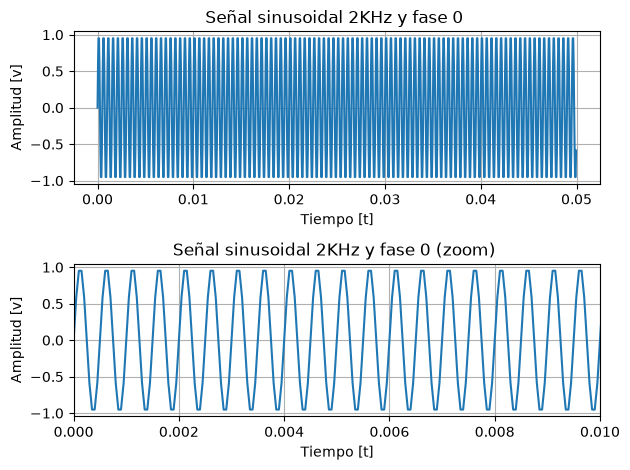

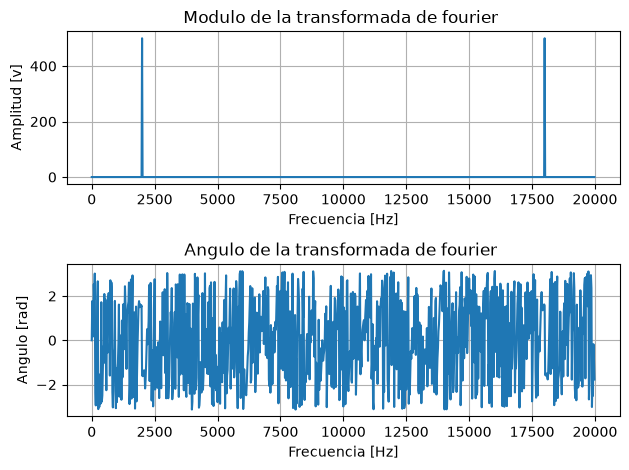

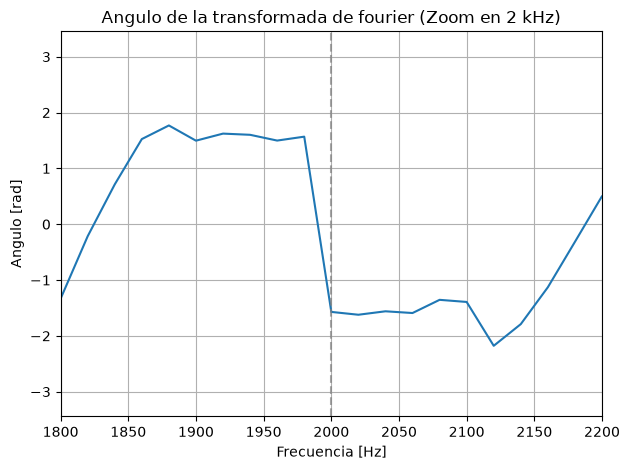

In [3]:
import numpy as np
import matplotlib.pyplot as plt
#import scipy.stats as stats
plt.close ("all")


fs = 20000          # para tener 2khz y 10 pts por periodo tengo que tomar 10 muestras por oscilacion
N = 1000            #Cantidad de muestras fijas

#Variables para ir cambiando y que cambie mi funcion
vmax = 1   #Amplitud maxima de mi señal
dc = 0              #Desplazamiento, me mueve mi señal que queda fija com vmax = 2 para el centro = dc
ff = 2000           # 2khz
ph = 0              #La fase        

def funcion_sen ( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    xx = (vmax * np.sin(2 * np.pi * ff * np.arange(nn)/fs + ph)) +dc
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    return (tt,xx)

def calculo_pot (pot = 1):
    vmax = np.sqrt(pot*2)
    return (vmax)



#%%
tt, xx = funcion_sen( vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
xfft = np.abs(np.fft.fft(xx))
angx = np.angle(np.fft.fft(xx))




plt.subplot (2,1,1)
plt.plot(tt,xx)
plt.title("Señal sinusoidal 2KHz y fase 0 ")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()

tt, xx = funcion_sen( vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs)
plt.subplot (2,1,2)
plt.plot(tt,xx)
plt.title("Señal sinusoidal 2KHz y fase 0 (zoom) ")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.xlim(0,0.01)
plt.grid()
plt.tight_layout()

plt.figure()
plt.subplot (2,1,1)
plt.plot(frec,xfft)
plt.title("Modulo de la transformada de fourier ")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [v]")
plt.grid()


plt.subplot (2,1,2)
plt.plot(frec,angx)
plt.title("Angulo de la transformada de fourier ")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Angulo [rad]")
plt.grid()
plt.tight_layout()

plt.figure()
plt.plot(frec, angx)
plt.xlim(1800, 2200)  # Rango de zoom alrededor de los 2000 Hz
plt.axvline(x=2000, color='gray', linestyle='--', alpha=0.7)  # Línea guía en 2 kHz
plt.title("Angulo de la transformada de fourier (Zoom en 2 kHz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Angulo [rad]")
plt.grid()
plt.tight_layout()


idx_2khz = np.where(frec == 2000)[0]
if len(idx_2khz) > 0:
    print(f"El ángulo de la transformada en 2000 Hz es de: {angx[idx_2khz[0]]:.4f} rad")



Analizando los gráficos se pueden ver varias cosas. Primero, que tenemos 2 picos en nuestra función del módulo de la transformada; esto se debe a que, debido a que la frecuencia de Nyquist está exactamente en $10\,000\text{ Hz}$, sabemos que la función va a ser un espejo de la otra de ahí en adelante. Por eso es que vemos el segundo pico en $18\,000\text{ Hz} = 20\,000\text{ Hz} - 2\,000\text{ Hz}$, es decir, si vamos de atrás para adelante hacia nuestra frecuencia de Nyquist, justo a los $2\,000\text{ Hz}$.

Luego, se puede ver en el gráfico que le hace zoom al ángulo de la transformada que este no da $0$ en $2\,000\text{ Hz}$ como esperaríamos por la fase que le pusimos ("0"), sino que da $-\pi/2$. Esto es debido a por cómo funciona la transformada, que interpreta al coseno como referencia —ya que este es la parte real de una exponencial compleja— y justamente la fase del coseno está retrasada respecto al seno en $-\pi/2$.

### Ejercicio 2:

El ángulo de la transformada en 2000 Hz es de: -0.0000 rad
Potencia calculada aprovechando Parseval: 2.0000


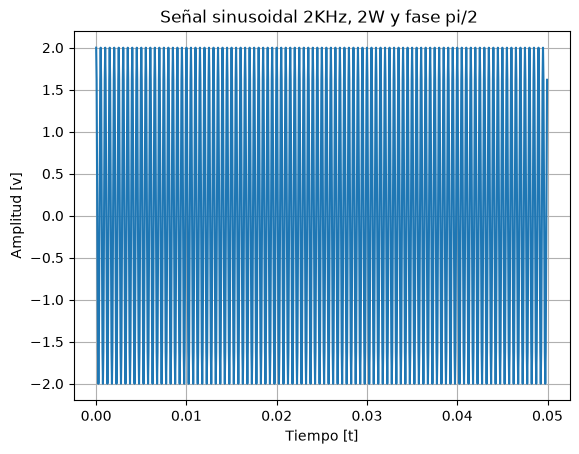

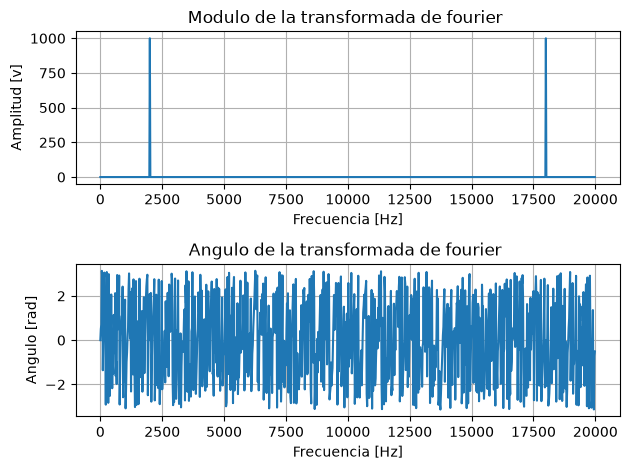

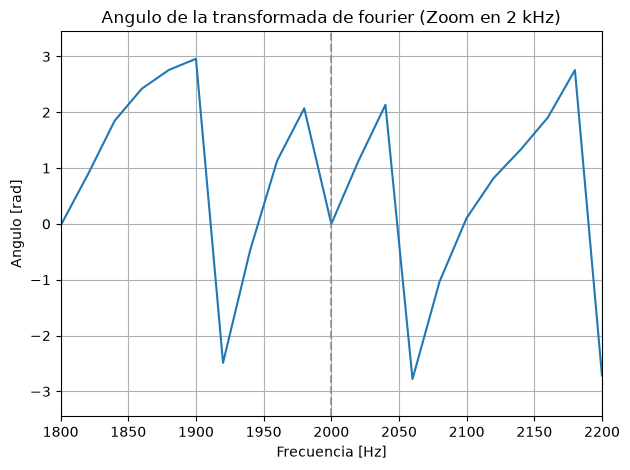

In [12]:
import numpy as np
import matplotlib.pyplot as plt
#import scipy.stats as stats
plt.close ("all")


fs = 20000          # para tener 2khz y 10 pts por periodo tengo que tomar 10 muestras por oscilacion
N = 1000            #Cantidad de muestras fijas

#Variables para ir cambiando y que cambie mi funcion
vmax = 1   #Amplitud maxima de mi señal
pot_in = 2             #Potencia de la señal
dc = 0             #Desplazamiento, me mueve mi señal que queda fija com vmax = 2 para el centro = dc
ff = 2000           # 2khz
ph = np.pi/2               #La fase





def funcion_sen ( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs):
    
    xx = (vmax * np.sin(2 * np.pi * ff * np.arange(nn)/fs + ph)) +dc
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    return (tt,xx)

def calculo_pot (pot = 1):
    vmax = np.sqrt(pot*2)
    return (vmax)




vmax = calculo_pot (pot_in)
tt, xx = funcion_sen( vmax = vmax, dc = dc, ff = ff, ph = ph, nn = N, fs = fs)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
xfft = np.abs(np.fft.fft(xx))
angx = np.angle(np.fft.fft(xx))




#plt.subplot (2,1,1)
plt.plot(tt,xx)
plt.title("Señal sinusoidal 2KHz, 2W y fase pi/2 ")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.grid()

plt.figure()
plt.subplot (2,1,1)
plt.plot(frec,xfft)
plt.title("Modulo de la transformada de fourier ")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [v]")
plt.grid()


plt.subplot (2,1,2)
plt.plot(frec,angx)
plt.title("Angulo de la transformada de fourier ")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Angulo [rad]")
plt.grid()
plt.tight_layout()


plt.figure()
plt.plot(frec, angx)
plt.xlim(1800, 2200)  # Rango de zoom alrededor de los 2000 Hz
plt.axvline(x=2000, color='gray', linestyle='--', alpha=0.7)  # Línea guía en 2 kHz
plt.title("Angulo de la transformada de fourier (Zoom en 2 kHz)")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Angulo [rad]")
plt.grid()
plt.tight_layout()


idx_2khz = np.where(frec == 2000)[0]
if len(idx_2khz) > 0:
    print(f"El ángulo de la transformada en 2000 Hz es de: {angx[idx_2khz[0]]:.4f} rad")
parseval = np.sum(np.abs(xfft)**2) / N /N 
print(f"Potencia calculada aprovechando Parseval: {parseval:.4f}")

Esta señal a diferencia de la anterior tiene una potencia de 2W por eso es que cambia la amplitud maxima de la señal, para poder calcular la potencia de una transformada, yo utilice el teorema de parceval $$\sum_{n=0}^{N-1} |x[n]|^2 = \frac{1}{N} \sum_{k=0}^{N-1} |X[k]|^2$$ que relaciona la energia de una señal con su transformada  y simplemente lo dividi dee nuevo por el numero de muestras para asi obtener la potencia.
Por otro lado se puede ver lo que se meciono en el ejercicio anterior acerca del defasaje del angulo ya que ahora que lo adelantamos en $\frac{\pi}{2}$ y por eso ahora el angulo en f = 2000Hz es 0

### Ejercicio 3:

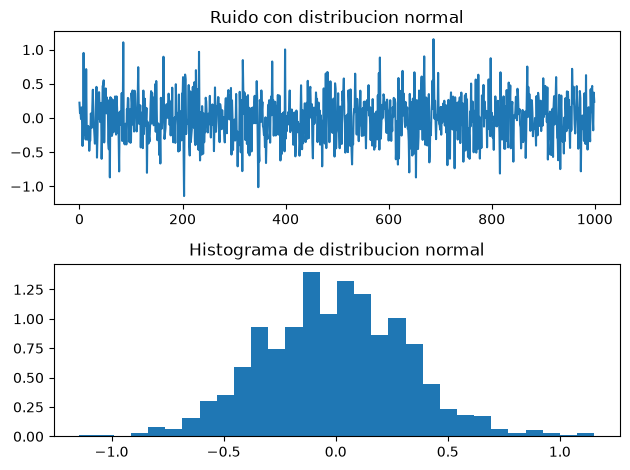

In [14]:
import numpy as np
import matplotlib.pyplot as plt
#import scipy.stats as stats
plt.close ("all")

var = 0.1


xx_rand_norm = np.random.normal(loc = 0, scale = np.sqrt(var), size = 1000)   # Distribucion normal
plt.figure()
plt.subplot(2,1,1)
plt.plot(xx_rand_norm)
plt.title("Ruido con distribucion normal")
plt.subplot(2,1,2)
plt.hist(xx_rand_norm, bins = 30, density = True)
plt.title("Histograma de distribucion normal")
plt.tight_layout()

### Ejercicio 4:

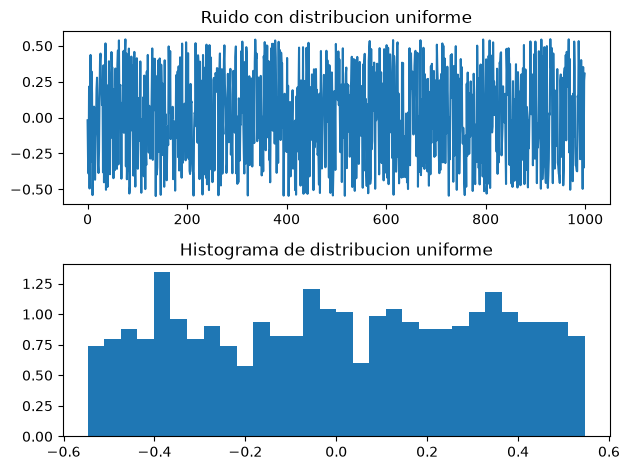

In [17]:
import numpy as np
import matplotlib.pyplot as plt
#import scipy.stats as stats
plt.close ("all")

var = 0.1



def ruido (SNR = 0, pot_in = 1):
    pot_r = 10**-((SNR/(-10))-np.log10(pot_in))
    limite = calculo_limites_unif(pot_r)
    xx_rand_unif = np.random.uniform(low = -limite, high = limite, size = 1000)
    return ( xx_rand_unif)

def calculo_limites_unif (var):
    limite = np.sqrt(12*var/4)
    return(limite)


limite = calculo_limites_unif(var) #calculo cuales tienen que ser los limites para tener la varianza de 0,1 que se busca
xx_rand_unif = np.random.uniform(low = -limite, high = limite, size = 1000)     

plt.figure()
plt.subplot(2,1,1)
plt.plot(xx_rand_unif)
plt.title("Ruido con distribucion uniforme")
plt.subplot(2,1,2)
plt.hist(xx_rand_unif, bins = 30, density = True)
plt.title("Histograma de distribucion uniforme")
plt.tight_layout()

### Ejercicio 5:

Potencia calculada aprovechando Parseval: 1.0000


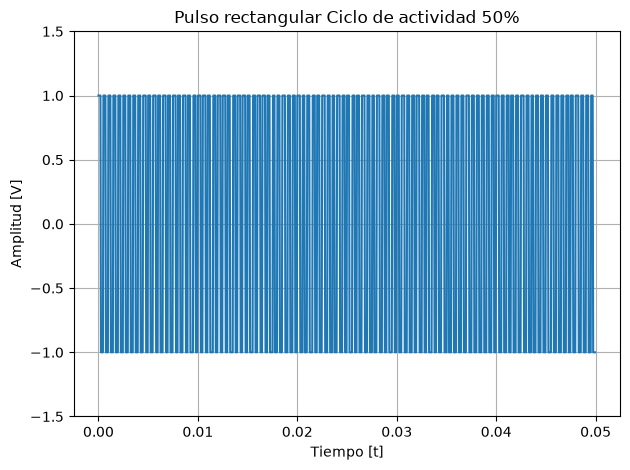

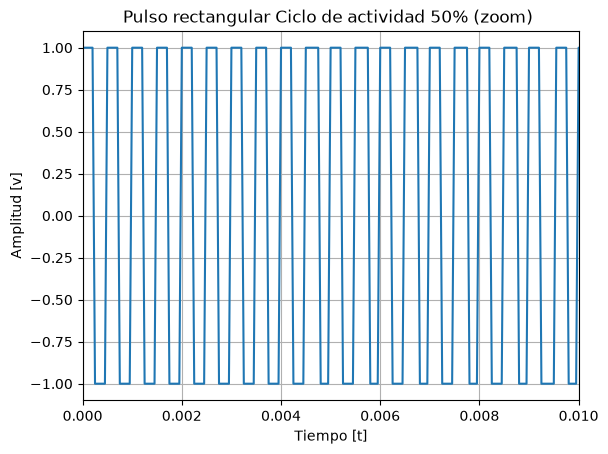

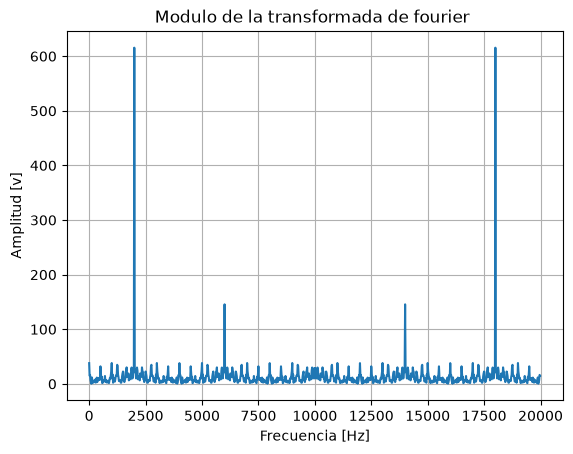

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import scipy as scp

fs = 20000          # para tener 2khz y 10 pts por periodo tengo que tomar 10 muestras por oscilacion
N = 1000            #Cantidad de muestras fijas

#Variables para ir cambiando y que cambie mi funcion
pot_in = 1  # Potencia deseada
vmax = np.sqrt(pot_in) #Amplitud para obtener la potencia deseada
dc = 0             #Desplazamiento, me mueve mi señal que queda fija com vmax = 2 para el centro = dc
ff = 2000           # 2khz
ph = np.pi/2               #La fase
SNR = -100          #Valor de SNR objetivo con potencia de entrada fija
var = 0.1
ciclo_act = 0.5



def funcion_rectangular (vmax = 1, dc = 0, ff = 1, ciclo_act = 0, nn = N, fs = fs):
  
    tt = np.arange(start=0, stop=nn/fs, step=1/fs)
    xx = vmax * scp.signal.square(2 * np.pi * ff * tt, ciclo_act)
    
    return (tt, xx)

tt_rect, xx_rect = funcion_rectangular(vmax = vmax, dc = dc, ff = ff, ciclo_act = ciclo_act, nn = N, fs = fs)
frec = np.arange(start=0,step=fs,stop=fs*N)/N
xfft = np.abs(np.fft.fft(xx_rect))
angx = np.angle(np.fft.fft(xx_rect))


plt.figure()
plt.plot(tt_rect, xx_rect)
plt.title("Pulso rectangular Ciclo de actividad 50%")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [V]")
plt.ylim(-1.5, 1.5)
plt.grid()
plt.tight_layout()

plt.figure()
plt.plot(tt_rect, xx_rect)
plt.title("Pulso rectangular Ciclo de actividad 50% (zoom) ")
plt.xlabel("Tiempo [t]")
plt.ylabel("Amplitud [v]")
plt.xlim(0,0.01)
plt.grid()

plt.figure()
plt.plot(frec,xfft)
plt.title("Modulo de la transformada de fourier ")
plt.xlabel("Frecuencia [Hz]")
plt.ylabel("Amplitud [v]")
plt.grid()

parseval = np.sum(np.abs(xfft)**2) / N /N 
print(f"Potencia calculada aprovechando Parseval: {parseval:.4f}")

A diferencia de una señal sinusoidal, se ven muchos picos aparte de los 2 que ya se veian, esto se debe que a diferencia de una señal sinusoidal, la señal rectangular no se puede representar con una sola frecuencia pero como dice el teorema de fourier, si se puede representar como una sumatoria de senos y cosenos cuyos picos son los que vemos, y los 2 picos que resaltan se encuentran exactamente en 6000Hz y 14000Hz que son el tercer armonico de la funcion que es el unico que se ve ya que al tener un ciclo de actividad del 50% los armonicos pares tienen una amplitud igual a 0 y los otros impares que le siguen a 3 tienen valores de amplitud muy bajos y se mezclan con el ruido de la señal.